# Filtering_and_fitting

In [1]:
# from 2f_amp_prop_script
import os
import json
import sqlite3
import numpy as np
from datetime import datetime, timedelta
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
import argparse
import hashlib
import filelock
import re
import sys  # Add missing import for sys

from Dpipe import repkg, pipe, timeseries_util as tsu, startup
from Dpipe import survey_span_gen as spg
from Dpipe.mss_util import extract_templates_from_span
from Dpipe.database_utils import get_database_spans
from Dpipe import mss_util as util
import vivian_fit as vfit

verbose=True

def log(msg):
    if verbose:
        print(msg, flush=True)

dpipe_path = os.getenv('DPIPE_PREFIX')

config = startup.DpipeConfig(os.path.join(dpipe_path, 'Dpipe/parameter_files/test-vt.yml'))
print(f"\nHWP config: recv={config.recv}, timeline={config.timeline}")
print(f"  UIDs: {config.uids}")


HWP config: recv=w1_band, timeline={'era4': 'w1_full'}
  UIDs: {'era4': [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 22, 23, 26, 29, 30, 32, 33, 44, 45, 47, 48, 49, 67, 68, 70, 71, 72, 74, 75, 76, 77, 79, 80, 81, 82, 84, 85, 86, 87, 89, 90, 91, 92, 94, 95, 96, 97, 98, 102, 103, 106, 110, 113, 114, 116, 119, 120, 121, 123, 124, 126, 127, 128, 129, 130, 132, 133, 135, 140, 141, 145, 148, 154, 156, 158, 159, 160, 161, 162, 163, 164, 167, 168, 169, 170, 172, 173, 174, 177, 180, 182, 183, 204, 205, 206, 208, 209, 211, 212, 214, 215, 216, 217, 220, 223, 224, 225, 226, 228, 229, 230, 231, 233, 235, 236, 239, 242, 243, 248, 253, 255, 257, 261, 262, 263, 264, 265, 266, 267, 268, 270, 272, 277, 280, 281, 282, 287, 289, 293, 294, 295, 301, 302, 303, 304, 305, 306, 309, 313, 314, 316, 317, 319, 320, 321, 323, 324, 326, 327, 330, 331, 332, 334, 336, 337, 338, 339, 340, 341, 343, 344, 346, 348, 349, 350, 351, 353, 355, 356, 358, 359, 360, 361, 362, 363, 365, 367, 368, 369, 37

In [2]:
PATH = '/data/users/class/mapmaking_in/dtod/w1_band'

log(f"Processing span: {PATH}")
log(f"Loading TOD for: {PATH}")
# option 1
# span = repkg.Span.from_path(PATH, config)
# option 2
hwp_t0 = datetime(2024, 11, 30, 23, 0, 0)
hwp_t1 = datetime(2024, 12, 1, 4, 0, 0)
print(f"\nHWP span: {hwp_t0} to {hwp_t1}")
print(f"  Expected name: {repkg.edges_to_name(hwp_t0, hwp_t1)}")

Processing span: /data/users/class/mapmaking_in/dtod/w1_band
Loading TOD for: /data/users/class/mapmaking_in/dtod/w1_band

HWP span: 2024-11-30 23:00:00 to 2024-12-01 04:00:00
  Expected name: 2024-11-30-23-00-00_31


In [3]:
span = repkg.Span(hwp_t0, hwp_t1, config)
span.load_tod(new_cache=False)

log("TOD loaded; initializing cuts")

if span.kill_build:
    print("  WARNING: Span marked for kill (idle or aborted scan)")
else:
    print(f"  Span name: {span.name}")
    print(f"  Detectors: {len(span.det_uid)} ({span.det_uid})")
    print(f"  Samples: {span.tod.nsamps:,} ({span.tod.nsamps/200:.1f} sec @ 200 Hz)")
    print(f"  Grid era: {span.grid_era}")
    print(f"  Boresight: {span.bs_name}deg")

TOD loaded; initializing cuts
  Span name: 2024-11-30-23-00-00_31
  Detectors: 345 ([0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 22, 23, 26, 29, 30, 32, 33, 44, 45, 47, 48, 49, 67, 68, 70, 71, 72, 74, 75, 76, 77, 79, 80, 81, 82, 84, 85, 86, 87, 89, 90, 91, 92, 94, 95, 96, 97, 98, 102, 103, 106, 110, 113, 114, 116, 119, 120, 121, 123, 124, 126, 127, 128, 129, 130, 132, 133, 135, 140, 141, 145, 148, 154, 156, 158, 159, 160, 161, 162, 163, 164, 167, 168, 169, 170, 172, 173, 174, 177, 180, 182, 183, 204, 205, 206, 208, 209, 211, 212, 214, 215, 216, 217, 220, 223, 224, 225, 226, 228, 229, 230, 231, 233, 235, 236, 239, 242, 243, 248, 253, 255, 257, 261, 262, 263, 264, 265, 266, 267, 268, 270, 272, 277, 280, 281, 282, 287, 289, 293, 294, 295, 301, 302, 303, 304, 305, 306, 309, 313, 314, 316, 317, 319, 320, 321, 323, 324, 326, 327, 330, 331, 332, 334, 336, 337, 338, 339, 340, 341, 343, 344, 346, 348, 349, 350, 351, 353, 355, 356, 358, 359, 360, 361, 362, 363, 365, 367, 3

In [4]:
span.init_cuts(config=config)
log("Cuts initialized; setting scan speed")
span.set_scan_speed(span)
log("Scan speed set; applying cut_and_fix")
pipe.cut_and_fix(span, config, verbose=True)
log("Cuts applied; calibrating TOD")


Cuts initialized; setting scan speed
Scan speed set; applying cut_and_fix
loading initial cuts
repairing relocks
finding flux jump density
repairing flux jumps
finding missed flux jumps
filling cuts
Cuts applied; calibrating TOD


In [17]:
print(span.config.cal_config_num)


8


In [5]:
tsu.cal_tod(span) ## 56lp is set to pwv calibration
log("Calibration done; running single_det")

Calibration done; running single_det


In [6]:
span.single_det() ## divides each detector by relative efficiency
log("single_det complete;")

single_det complete;


In [7]:
# -------------------MAKE SURE FILTERING DOES EDIT ANY ACTUAL DATA IN PLACE-----------------------------
#filtered_span_data = util.filter_span_data(span, verbose=True) # bandpass filter around 2f
filtered_span_data = vfit.filter_span_data(span, freq_mult=2, verbose=True) # bandpass filter around 2f

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import datetime
# fig, ax = plt.subplots(figsize=(14,5))
# plt.plot(pd.to_datetime(span.tod.ctime, unit="s", utc=True), filtered_span_data['filtered_data'][0])

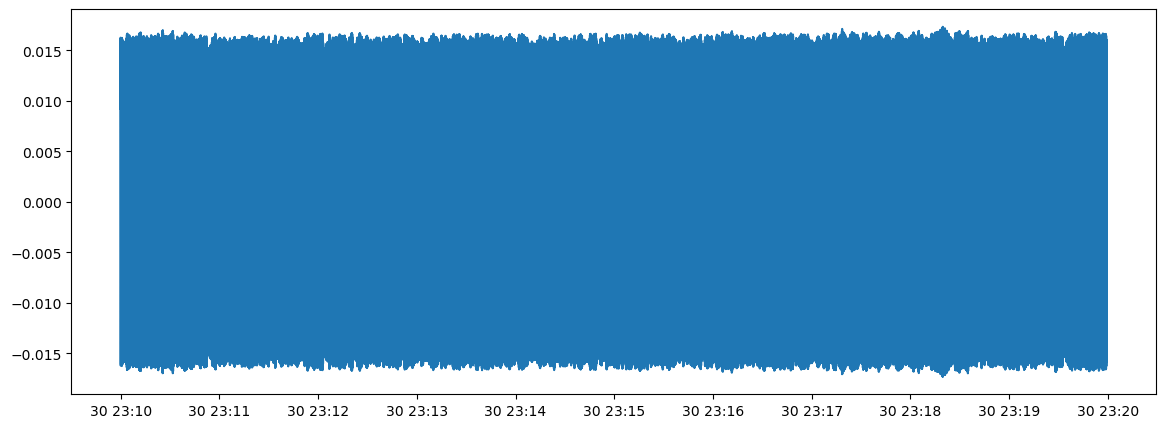

In [34]:
fig, ax = plt.subplots(figsize=(14,5))
plt.plot(pd.to_datetime(span.tod.ctime, unit="s", utc=True)[120800:120800+120600], filtered_span_data['filtered_data'][0][120800:120800+120600])

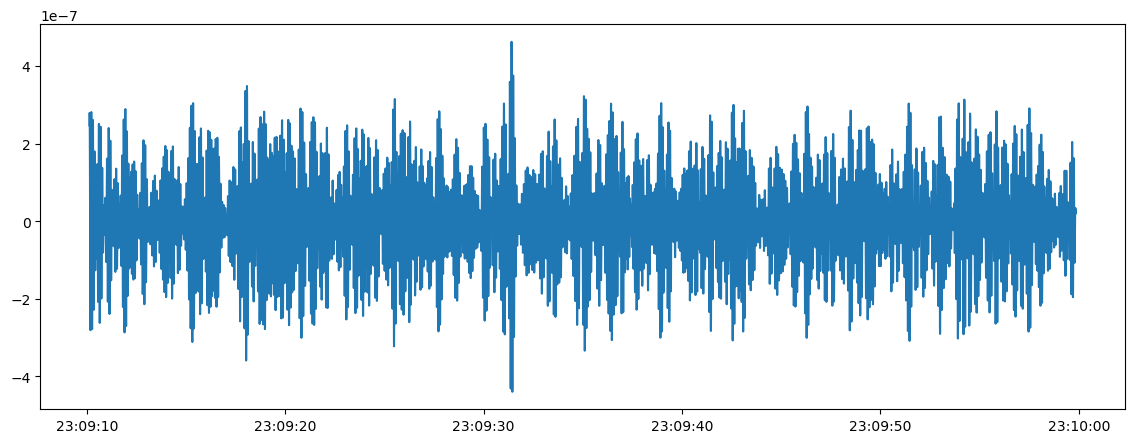

In [36]:
fig, ax = plt.subplots(figsize=(14,5))
plt.plot(pd.to_datetime(span.tod.ctime, unit="s", utc=True)[120800-10000:120800], filtered_span_data['filtered_data'][2][120800-10000:120800])

In [10]:
filtered_data = filtered_span_data['filtered_data']
uncut_dets = filtered_span_data['uncut_dets']
det_uids = filtered_span_data['det_uids']
encoder_data = filtered_span_data['encoder_data']

print(len(filtered_data), len(uncut_dets), len(det_uids))

345 334 334


In [13]:
bin_count = 360
phase = encoder_data % 180
bins = np.linspace(0, 180, bin_count + 1)
bin_idx = np.digitize(phase, bins) - 1
print(bins[:5])
print(bin_idx[:5])

[0.  0.5 1.  1.5 2. ]
[322 333 344 355   5]


# Fit evaluation

In [13]:
def extract_templates(filtered_span_data, binning=False, bin_med=False, n=1):
    # Get span's filtered data
    filtered_data = filtered_span_data['filtered_data']
    uncut_dets = filtered_span_data['uncut_dets']
    det_uids = filtered_span_data['det_uids']
    encoder_data = filtered_span_data['encoder_data']
    modulator_type = filtered_span_data['modulator_type']
    mod_freq = filtered_span_data['mod_freq']
    full_cut_masks = filtered_span_data['cut_masks']

    results = {}

    # break_points = np.append(span.pkg_edges, span.tod.nsamps)
    # slices = [slice(_[0], _[1]) for _ in zip(break_points[:-1], break_points[1:])]


    # split into segments by datapkg
    slices = span.get_segments(unit='dpkg')
    # slices = span.get_segments(unit='sec', n = 60)
    if n != 1:
        small_slices = []
        for dpkg in slices:
            start = dpkg.start
            stop = dpkg.stop

            edges = np.linspace(start, stop, n + 1).astype(int)

            for i in range(n):
                small_slices.append(slice(edges[i], edges[i+1]))

        slices = small_slices
    k = 0

    for dpkg in slices:
        seg_results = {}
        theta = np.deg2rad(encoder_data[dpkg])

        if binning:
            # bin_count = min(360, int(180.0 / max(0.5, np.median(np.diff(np.sort(np.unique(encoder_data)))))))
            bin_count = 360
            phase = encoder_data[dpkg] % 180
            bins = np.linspace(0, 180, bin_count + 1) # bin edges
            bin_idx = np.digitize(phase, bins) - 1 # index of which bin each piece of data goes into 

            bin_centers = (bins[1:] + bins[:-1]) / 2 # find middle of bin edges
            
        for i in range(len(uncut_dets)): #uncut_dets stores tod indices of detectors with at least 1 uncut sample
            signal = filtered_data[uncut_dets[i],dpkg]

            # try phase folding and with raw data
            if binning:

                template = np.zeros(bin_count) # mean signal at each bin
                template_errors = np.zeros(bin_count)
                bin_size = np.zeros(bin_count, dtype=int)

                for j in range(bin_count):
                    samples = signal[bin_idx == j]

                    bin_size[j] = len(samples)

                    if len(samples) > 0:
                        if bin_med:
                            template[j] = np.median(samples)
                        else:
                            template[j] = np.mean(samples)

                        if len(samples) > 1:
                            template_errors[j] = np.std(samples, ddof=1) / np.sqrt(len(samples))

                # Check if we have enough binned data
                valid_bins = bin_size > 0
                if np.sum(valid_bins) < 0.5 * bin_count:
                    template_result = {'template': None, 'template_errors': None, 'bin_centers': bin_centers, 'valid': False,
                            'mod_freq': mod_freq, 'bin_counts': bin_size}
                else:
                    theta_bin = np.deg2rad(bin_centers[valid_bins])
                    matrix = np.column_stack([
                        np.cos(2 * theta_bin),
                        np.sin(2 * theta_bin),
                        np.ones_like(theta_bin)
                    ])

                    coef, *_ = np.linalg.lstsq(matrix, template[valid_bins], rcond=None)

                    A, B, C = coef
                    template_fit_2f = matrix @ np.array([A, B, C])
                    ss_res = np.sum((template[valid_bins] - template_fit_2f[valid_bins])**2)
                    ss_tot = np.sum((template[valid_bins] - np.mean(template[valid_bins]))**2)
                    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

                    amplitude = np.sqrt(A**2 + B**2)

                    template_result = {'amplitude': amplitude, 'scaling_factor': 1.0, 'quality': r2, 'A':A, 'B': B, 'C':C, 'segment_id': k}

                
            else:
                matrix = np.column_stack([
                    np.cos(2 * theta),
                    np.sin(2 * theta),
                    np.ones_like(theta)
                ])

                coef, *_ = np.linalg.lstsq(matrix, signal, rcond=None)

                A, B, C = coef
                fit_2f = matrix @ np.array([A, B, C])
                ss_res = np.sum((signal - fit_2f)**2)
                ss_tot = np.sum((signal - np.mean(signal))**2)
                r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

                amplitude = np.sqrt(A**2 + B**2)

                template_result = {'amplitude': amplitude, 'scaling_factor': 1.0, 'quality': r2, 'A':A, 'B': B, 'C':C, 'segment_id': k}

            det_uid = det_uids[i] # det uid in order of indexing of tod
            seg_results[det_uid] = template_result
        k += 1

        if seg_results:
            pkg_timestamp = span.tod.ctime[dpkg.start]
            # segment_meta = {
            #     'modulator_type': modulator_type,
            #     'mod_freq': mod_freq
            # }
            # results[str(pkg_timestamp)] = {
            #     #'_meta': segment_meta,
            #     'detectors': seg_results
            # }
            results[str(pkg_timestamp)] = seg_results

    return results



In [14]:
one_minute_span1 = extract_templates(filtered_span_data, binning = True, bin_med = False, n = 10)

In [11]:
test_raw_fitting = extract_templates(filtered_span_data)

In [12]:
phase_folded_fitting_mean = extract_templates(filtered_span_data, binning=True, bin_med=False)

In [13]:
phase_folded_fitting_med = extract_templates(filtered_span_data, binning=True, bin_med=True)

In [18]:
test_raw_fitting_half = extract_templates(filtered_span_data, binning=False, n = 2)

In [20]:
test_raw_fitting_quarter = extract_templates(filtered_span_data, binning=False, n = 4)

In [21]:
phase_folded_fitting_mean_half = extract_templates(filtered_span_data, binning=True, bin_med=False, n = 2)
phase_folded_fitting_mean_quarter = extract_templates(filtered_span_data, binning=True, bin_med=False, n = 4)

In [22]:
phase_folded_fitting_med_half = extract_templates(filtered_span_data, binning=True, bin_med=True, n = 2)
phase_folded_fitting_med_quarter = extract_templates(filtered_span_data, binning=True, bin_med=True, n = 4)

In [23]:
dicts = [test_raw_fitting, test_raw_fitting_half, test_raw_fitting_quarter, 
         phase_folded_fitting_mean, phase_folded_fitting_mean_half, phase_folded_fitting_mean_quarter, 
         phase_folded_fitting_med, phase_folded_fitting_med_half, phase_folded_fitting_med_quarter]
dataframes = []
for i in range(len(dicts)):
    rows = []

    for timestamp, detectors in dicts[i].items():
        for det_id, values in detectors.items():
            rows.append({
                "timestamp": float(timestamp),   # or pd.to_datetime(float(timestamp), unit="s")
                "det_id": det_id,
                "amplitude": values["amplitude"],
                "scaling_factor": values["scaling_factor"],
                "quality": values["quality"],
                "A": values['A'],
                "B": values['B'],
                "C": values['C']
            })

    dataframes.append(pd.DataFrame(rows))

(
    raw_fit, raw_fit_half, raw_fit_quarter,
    phase_fold_mean, phase_fold_mean_half, phase_fold_mean_quarter,
    phase_fold_med, phase_fold_med_half, phase_fold_med_quarter
) = dataframes


In [15]:
rows = []

for timestamp, detectors in one_minute_span1.items():
    for det_id, values in detectors.items():
        rows.append({
            "timestamp": float(timestamp),   # or pd.to_datetime(float(timestamp), unit="s")
            "det_id": det_id,
            "amplitude": values["amplitude"],
            "scaling_factor": values["scaling_factor"],
            "quality": values["quality"],
            "A": values['A'],
            "B": values['B'],
            "C": values['C'],
            "segment_id": values['segment_id']
        })

df = pd.DataFrame(rows)
df.to_csv("one_minute_span1.csv", index=False)

In [17]:
one_minute_span1_fit = pd.read_csv(f"one_minute_span1.csv")

In [9]:
names = [
    "raw_fit",
    "raw_fit_half",
    "raw_fit_quarter",
    "phase_fold_mean",
    "phase_fold_mean_half",
    "phase_fold_mean_quarter",
    "phase_fold_med",
    "phase_fold_med_half",
    "phase_fold_med_quarter"
]

In [28]:
for name, df in zip(names, dataframes):
    df.to_csv(f"{name}.csv", index=False)

In [75]:
slices = span.get_segments(unit='dpkg')
n = 2
half_slices = []
for dpkg in slices:
    start = dpkg.start
    stop = dpkg.stop

    edges = np.linspace(start, stop, n + 1).astype(int)

    for i in range(n):
        half_slices.append(slice(edges[i], edges[i+1]))

n = 4
quarter_slices = []
for dpkg in slices:
    start = dpkg.start
    stop = dpkg.stop

    edges = np.linspace(start, stop, n + 1).astype(int)

    for i in range(n):
        quarter_slices.append(slice(edges[i], edges[i+1]))


In [11]:
import pandas as pd
loaded_dataframes = []

for name in names:
    df = pd.read_csv(f"{name}.csv")
    loaded_dataframes.append(df)

(
    raw_fit, raw_fit_half, raw_fit_quarter,
    phase_fold_mean, phase_fold_mean_half, phase_fold_mean_quarter,
    phase_fold_med, phase_fold_med_half, phase_fold_med_quarter
) = loaded_dataframes

In [77]:
raw_fit["segment_id"] = raw_fit.groupby("timestamp").ngroup()
raw_fit_half["segment_id"] = raw_fit_half.groupby("timestamp").ngroup()
raw_fit_quarter["segment_id"] = raw_fit_quarter.groupby("timestamp").ngroup()
phase_fold_mean["segment_id"] = phase_fold_mean.groupby("timestamp").ngroup()
phase_fold_mean_half["segment_id"] = phase_fold_mean_half.groupby("timestamp").ngroup()
phase_fold_mean_quarter["segment_id"] = phase_fold_mean_quarter.groupby("timestamp").ngroup()
phase_fold_med["segment_id"] = phase_fold_med.groupby("timestamp").ngroup()
phase_fold_med_half["segment_id"] = phase_fold_med_half.groupby("timestamp").ngroup()
phase_fold_med_quarter["segment_id"] = phase_fold_med_quarter.groupby("timestamp").ngroup()
raw_fit

,timestamp,det_id,amplitude,scaling_factor,quality,A,B,C,segment_id
0,1.733008e+09,0,1.606417e-02,1.0,0.999162,6.724585e-03,-1.458895e-02,3.209737e-07,0
1,1.733008e+09,1,1.920127e-02,1.0,0.999178,-3.915062e-03,1.879791e-02,-5.490332e-07,0
2,1.733008e+09,2,1.117972e-09,1.0,0.000075,-6.089922e-10,-9.375444e-10,-2.112163e-11,0
3,1.733008e+09,3,1.549916e-02,1.0,0.999195,6.640811e-03,-1.400441e-02,3.180700e-07,0
4,1.733008e+09,4,1.684985e-02,1.0,0.999178,-3.488025e-03,1.648488e-02,-4.774287e-07,0
...,...,...,...,...,...,...,...,...,...
10349,1.733026e+09,609,2.848205e-02,1.0,0.999655,-3.162928e-03,2.830589e-02,-1.282744e-06,30
10350,1.733026e+09,612,3.009012e-02,1.0,0.999600,-1.814031e-03,3.003539e-02,-1.356999e-06,30
10351,1.733026e+09,613,2.249948e-02,1.0,0.999733,1.217002e-02,-1.892398e-02,8.003859e-07,30
10352,1.733026e+09,614,3.180717e-03,1.0,0.998200,2.994650e-03,-1.071931e-03,1.292772e-07,30


In [55]:
raw_bad = raw_fit[raw_fit["quality"] < 0.7]
mean_bad = phase_fold_mean[phase_fold_mean["quality"] < 0.7]
med_bad = phase_fold_med[phase_fold_med["quality"] < 0.7]

# Create identifiers for each bad row
raw_ids = set(zip(raw_bad["timestamp"], raw_bad["det_id"]))
mean_ids = set(zip(mean_bad["timestamp"], mean_bad["det_id"]))
med_ids = set(zip(med_bad["timestamp"], med_bad["det_id"]))

# Overlaps
raw_mean_overlap = raw_ids & mean_ids
raw_med_overlap = raw_ids & med_ids
mean_med_overlap = mean_ids & med_ids

all_overlap = raw_ids & mean_ids & med_ids

print("Number of bad rows:")
print(f"raw: {len(raw_ids)}")
print(f"phase mean: {len(mean_ids)}")
print(f"phase med: {len(med_ids)}")

print("\nPairwise overlap:")
print(f"raw and mean: {len(raw_mean_overlap)}")
print(f"raw and med: {len(raw_med_overlap)}")
print(f"mean and med: {len(mean_med_overlap)}")

print("\nAll three overlap:")
print(len(all_overlap))

print("raw bad rows also bad in mean:",
      len(raw_mean_overlap) / len(raw_ids))

print("raw bad rows also bad in med:",
      len(raw_med_overlap) / len(raw_ids))

print("mean bad rows also bad in med:",
      len(mean_med_overlap) / len(mean_ids))

Number of bad rows:
raw: 652
phase mean: 436
phase med: 499

Pairwise overlap:
raw and mean: 436
raw and med: 499
mean and med: 435

All three overlap:
435
raw bad rows also bad in mean: 0.6687116564417178
raw bad rows also bad in med: 0.7653374233128835
mean bad rows also bad in med: 0.9977064220183486


# fitting with vfit

In [ ]:
1

Extracting templates from 31 segments...


In [12]:
test_bin_mean = vfit.extract_templates_from_span(span, filtered_span_data, binning=True, bin_med=False, n=1, verbose=True)

Extracting templates from 31 segments...


In [41]:
fit_4f = vfit.extract_templates_from_span(span, filtered_span_data, binning=False, bin_med=False, n=10, verbose=True)

Extracting templates from 310 segments...


In [13]:
rows = []

for timestamp, detectors in test_bin_mean.items():
    for det_id, values in detectors.items():
        rows.append({
            "timestamp": float(timestamp),   # or pd.to_datetime(float(timestamp), unit="s")
            "det_id": det_id,
            "amplitude": values["amplitude"],
            "scaling_factor": values["scaling_factor"],
            "quality": values["quality"],
            "A": values['A'],
            "B": values['B'],
            "C": values['C'],
            "segment_id": values['segment_id']
        })

test_phase_fold_mean = pd.DataFrame(rows)

rows = []

for timestamp, detectors in test_raw.items():
    for det_id, values in detectors.items():
        rows.append({
            "timestamp": float(timestamp),   # or pd.to_datetime(float(timestamp), unit="s")
            "det_id": det_id,
            "amplitude": values["amplitude"],
            "scaling_factor": values["scaling_factor"],
            "quality": values["quality"],
            "A": values['A'],
            "B": values['B'],
            "C": values['C'],
            "segment_id": values['segment_id']
        })

test_raw_fit = pd.DataFrame(rows)

In [38]:


rows = []

for timestamp, detectors in fit_4f.items():
    for det_id, values in detectors.items():
        rows.append({
            "timestamp": float(timestamp),   # or pd.to_datetime(float(timestamp), unit="s")
            "det_id": det_id,
            "amplitude": values["amplitude"],
            "scaling_factor": values["scaling_factor"],
            "quality": values["quality"],
            "A": values['A'],
            "B": values['B'],
            "C": values['C'],
            "segment_id": values['segment_id']
        })

df_4f = pd.DataFrame(rows)

In [42]:
rows = []

for timestamp, detectors in fit_4f.items():
    for det_id, values in detectors.items():
        rows.append({
            "timestamp": float(timestamp),   # or pd.to_datetime(float(timestamp), unit="s")
            "det_id": det_id,
            "amplitude": values["amplitude"],
            "scaling_factor": values["scaling_factor"],
            "quality": values["quality"],
            "A": values['A'],
            "B": values['B'],
            "C": values['C'],
            "segment_id": values['segment_id']
        })

df_4f_minute = pd.DataFrame(rows)

In [20]:
test_phase_fold_mean.to_csv("new_phase_fold_mean.csv", index=False)

In [19]:
print("Fitting with full datapkg")
print(f"{'binning type':>25}{'mean quality':>20} {'std quality':>20}")
print(f"{'unbinned':>25}{np.mean(test_raw_fit['quality']):>20.8f} {np.std(test_raw_fit['quality']):>20.8f}")
print(f"{'phase fold mean':>25}{np.mean(test_phase_fold_mean['quality']):>20.8f} {np.std(test_phase_fold_mean['quality']):>20.8f} ")


Fitting with full datapkg
             binning type        mean quality          std quality
                 unbinned          0.93901767           0.22519247
          phase fold mean          0.93901767           0.22519247 


Text(0, 0.5, 'Frequency')

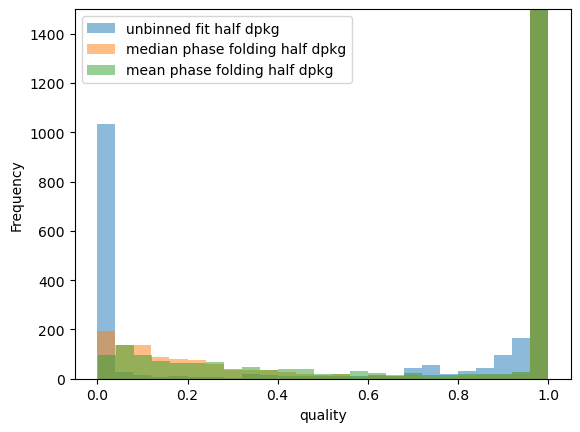

In [75]:
plt.hist(raw_fit_half['quality'], bins=25, label='unbinned fit half dpkg', alpha=0.5)
plt.hist(phase_fold_med_half['quality'], bins=25, label='median phase folding half dpkg', alpha=0.5)
plt.hist(phase_fold_mean_half['quality'], bins=25, label='mean phase folding half dpkg', alpha=0.5)

plt.legend()
#plt.xlim(0,0.8)
plt.ylim(0,1500)
plt.xlabel("quality")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

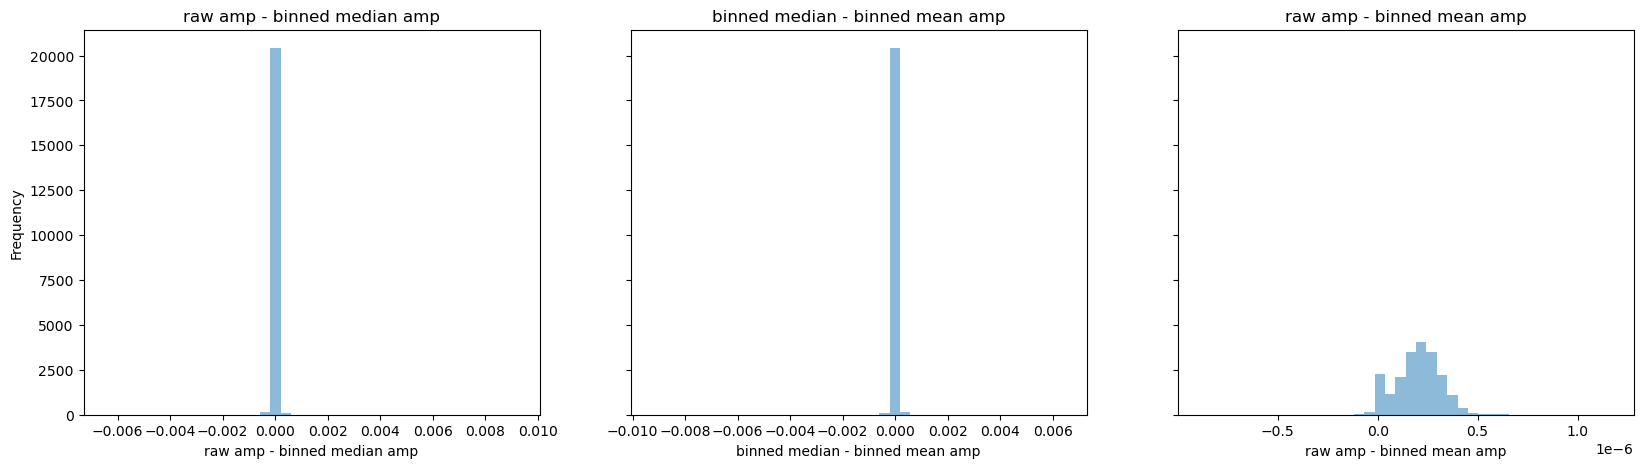

In [66]:
fig,ax = plt.subplots(1,3, figsize=(20,5), sharey=True)
ax[0].hist(raw_fit_half['amplitude']-phase_fold_med_half['amplitude'], bins=40, label='unbinned - median', alpha=0.5)
ax[0].set_title("raw amp - binned median amp")
ax[0].set_xlabel("raw amp - binned median amp")
ax[1].hist(phase_fold_med_half['amplitude']-phase_fold_mean_half['amplitude'], bins=40, label='median - mean', alpha=0.5)
ax[1].set_title("binned median - binned mean amp")
ax[1].set_xlabel("binned median - binned mean amp")
ax[2].hist(raw_fit_half['amplitude']-phase_fold_mean_half['amplitude'], bins=40, label='unbinned - mean', alpha=0.5)
ax[2].set_title("raw amp - binned mean amp")
ax[2].set_xlabel("raw amp - binned mean amp")

#plt.legend()
#plt.xlim(0,0.8)

ax[0].set_ylabel("Frequency")

In [67]:
# ADD a plot of (median amp - mean amp fitted) vs. some characteristic of noise in TOD

In [73]:
print("MEAN QUALITY OF FITS")
print(f"{'binning type':>25}{'full dpkg':>20} {'half dpkg':>20} {'quarter dpkg':>20}")
print(f"{'unbinned':>25}{np.mean(raw_fit['quality']):>20.6f} {np.mean(raw_fit_half['quality']):>20.6f} {np.mean(raw_fit_quarter['quality']):>20.6f}")
print(f"{'phase fold mean':>25}{np.mean(phase_fold_mean['quality']):>20.6f} {np.mean(phase_fold_mean_half['quality']):>20.6f} {np.mean(phase_fold_mean_quarter['quality']):>20.6f}")
print(f"{'phase fold med':>25}{np.mean(phase_fold_med['quality']):>20.6f} {np.mean(phase_fold_med_half['quality']):>20.6f} {np.mean(phase_fold_med_quarter['quality']):>20.6f}")

print("\n\n")
print("STANDARD DEVIATION OF QUALITY OF FITS")
print(f"{'binning type':>25}{'full dpkg':>20} {'half dpkg':>20} {'quarter dpkg':>20}")
print(f"{'unbinned':>25}{np.std(raw_fit['quality']):>20.6f} {np.std(raw_fit_half['quality']):>20.6f} {np.std(raw_fit_quarter['quality']):>20.6f}")
print(f"{'phase fold mean':>25}{np.std(phase_fold_mean['quality']):>20.6f} {np.std(phase_fold_mean_half['quality']):>20.6f} {np.std(phase_fold_mean_quarter['quality']):>20.6f}")
print(f"{'phase fold med':>25}{np.std(phase_fold_med['quality']):>20.6f} {np.std(phase_fold_med_half['quality']):>20.6f} {np.std(phase_fold_med_quarter['quality']):>20.6f}")

MEAN QUALITY OF FITS
             binning type           full dpkg            half dpkg         quarter dpkg
                 unbinned            0.938929             0.939543             0.940172
          phase fold mean            0.966985             0.964849             0.962907
           phase fold med            0.959681             0.959911             0.958626



STANDARD DEVIATION OF QUALITY OF FITS
             binning type           full dpkg            half dpkg         quarter dpkg
                 unbinned            0.225550             0.226410             0.225740
          phase fold mean            0.157734             0.162650             0.168452
           phase fold med            0.179646             0.178773             0.182302


In [19]:
row = raw_fit[
    (raw_fit["segment_id"] == 0) &
    (raw_fit["det_id"] == 2)
]
row

,timestamp,det_id,amplitude,scaling_factor,quality,A,B,C,segment_id
2,1.733008e+09,2,1.117972e-09,1.0,0.000075,-6.089922e-10,-9.375444e-10,-2.112163e-11,0


                     type                   A                    B Total Amplitude      Quality
                 unbinned       -6.089922e-10        -9.375444e-10        1.117972e-09     0.000075
            binned median        9.719839e-11         7.670165e-10        7.731506e-10     0.013870
              binned mean       -6.079288e-10        -9.354687e-10        1.115652e-09     0.047443


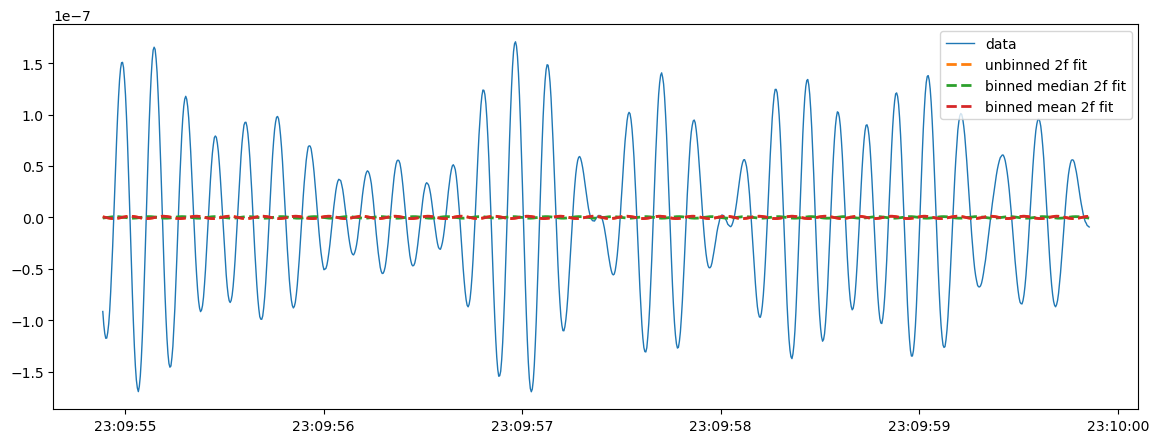

In [22]:
fig, ax = plt.subplots(figsize=(14,5))
slices = span.get_segments(unit='dpkg')

det = 2
i = 0

idx = slice(120800-1000, 120800)
zoom_slice = slice(slices[i].stop - 1000, slices[i].stop)
#zoom_slice = slices[0]

x = pd.to_datetime(span.tod.ctime, unit="s", utc=True)[zoom_slice]
det_index = filtered_span_data['det_uids'].index(det)

data = filtered_span_data['filtered_data'][det_index, zoom_slice]

encoder_data = filtered_span_data['encoder_data']
theta_slice = np.deg2rad(encoder_data[zoom_slice])

row = raw_fit[
    (raw_fit["segment_id"] == i) &
    (raw_fit["det_id"] == det)
]
print(f"{'type':>25}{'A':>20} {'B':>20} {'Total Amplitude':>12} {'Quality':>12}")
print(f"{'unbinned':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
fit = float(row['B'].iloc[0])*np.sin(2*theta_slice) + float(row['A'].iloc[0])*np.cos(2*theta_slice)
row = phase_fold_med[
    (phase_fold_med["segment_id"] == i) &
    (phase_fold_med["det_id"] == det)
]
print(f"{'binned median':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
phase_fold_med_fit = float(row['B'].iloc[0])*np.sin(2*theta_slice) + float(row['A'].iloc[0])*np.cos(2*theta_slice)

row = phase_fold_mean[
    (phase_fold_mean["segment_id"] == i) &
    (phase_fold_mean["det_id"] == det)
]
print(f"{'binned mean':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
phase_fold_mean_fit = float(row['B'].iloc[0])*np.sin(2*theta_slice) + float(row['A'].iloc[0])*np.cos(2*theta_slice)

plt.plot(x, data, label="data", linewidth=1)
plt.plot(x, fit, label="unbinned 2f fit", linestyle="--", linewidth=2)
plt.plot(x, phase_fold_med_fit, label="binned median 2f fit", linestyle="--", linewidth=2)
plt.plot(x, phase_fold_mean_fit, label="binned mean 2f fit", linestyle="--", linewidth=2)
plt.legend()

In [81]:
det = 2
i = 0

encoder_data = filtered_span_data['encoder_data']
filtered_data = filtered_span_data['filtered_data']

row = phase_fold_mean[
    (phase_fold_mean["segment_id"] == i) &
    (phase_fold_mean["det_id"] == det)
]

theta = np.deg2rad(encoder_data[slices[i]])
signal = filtered_data[det,slices[i]]

matrix = np.column_stack([
    np.cos(2 * theta),
    np.sin(2 * theta),
    np.ones_like(theta)
])

fit_2f = matrix @ np.array([row['A'].iloc[0], row['B'].iloc[0], row['C'].iloc[0]])
ss_res = np.sum((signal - fit_2f)**2)
ss_tot = np.sum((signal - np.mean(signal))**2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
print(r2)

2.7075039140789237e-05


Text(0.5, 0.98, 'Phase Folded Filtered Data')

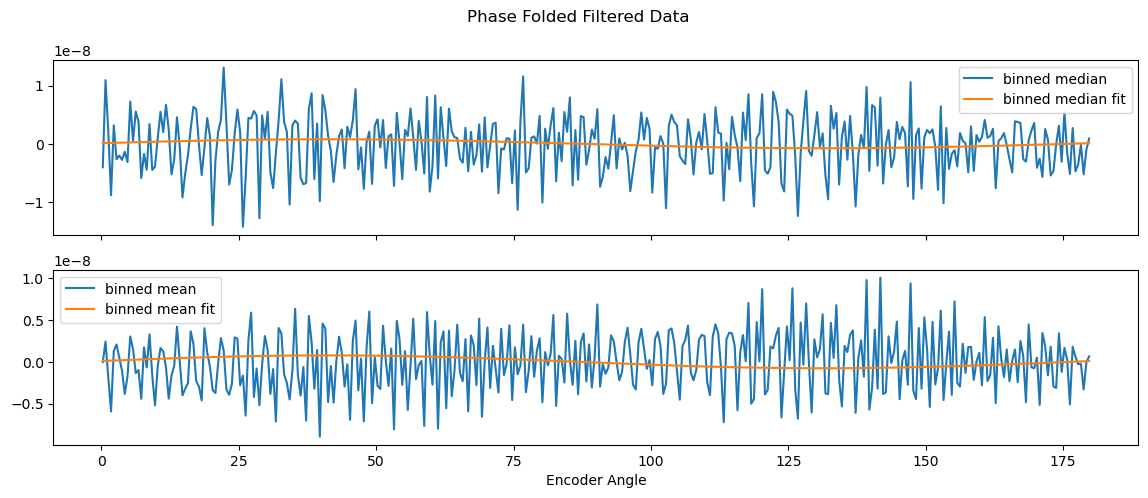

In [52]:
fig, ax = plt.subplots(2,1, sharex=True, figsize=(14,5))
slices = span.get_segments(unit='dpkg')

det = 2
i = 0
theta = np.deg2rad(encoder_data[slices[i]])
det_index = filtered_span_data['det_uids'].index(det)
bin_med = True

# bin_count = min(360, int(180.0 / max(0.5, np.median(np.diff(np.sort(np.unique(encoder_data)))))))
bin_count = 360
phase = encoder_data[slices[i]] % 180
bins = np.linspace(0, 180, bin_count + 1) # bin edges
bin_idx = np.digitize(phase, bins) - 1 # index of which bin each piece of data goes into 

bin_centers = (bins[1:] + bins[:-1]) / 2 # find middle of bin edges

signal = filtered_data[det_index,slices[i]]

# try phase folding and with raw data

template_med = np.zeros(bin_count) # mean signal at each bin
template_mean = np.zeros(bin_count) # mean signal at each bin
template_errors = np.zeros(bin_count)
bin_size = np.zeros(bin_count, dtype=int)

for j in range(bin_count):
    samples = signal[bin_idx == j]

    bin_size[j] = len(samples)

    if len(samples) > 0:
        template_med[j] = np.median(samples)
        template_mean[j] = np.mean(samples)

        if len(samples) > 1:
            template_errors[j] = np.std(samples, ddof=1) / np.sqrt(len(samples))

row = phase_fold_med[
    (phase_fold_med["segment_id"] == i) &
    (phase_fold_med["det_id"] == det)
]
phase_fold_med_fit = (
    float(row['A'].iloc[0]) * np.cos(2 * np.deg2rad(bin_centers))
    + float(row['B'].iloc[0]) * np.sin(2 * np.deg2rad(bin_centers))
)
row = phase_fold_med[
    (phase_fold_mean["segment_id"] == i) &
    (phase_fold_mean["det_id"] == det)
]
phase_fold_mean_fit = (
    float(row['A'].iloc[0]) * np.cos(2 * np.deg2rad(bin_centers))
    + float(row['B'].iloc[0]) * np.sin(2 * np.deg2rad(bin_centers))
)

ax[0].plot(bin_centers, template_med, label='binned median')
ax[0].plot(bin_centers, phase_fold_med_fit, label='binned median fit')
ax[1].plot(bin_centers, template_mean, label='binned mean')
ax[1].plot(bin_centers, phase_fold_mean_fit, label='binned mean fit')
ax[0].legend()
ax[1].legend()
plt.xlabel("Encoder Angle")
plt.suptitle("Phase Folded Filtered Data")

                     type                   A                    B Total Amplitude      Quality
                 unbinned        6.981054e-03        -1.560742e-02        1.709757e-02     0.999483
            binned median        6.988397e-03        -1.564051e-02        1.713077e-02     0.999999
              binned mean        6.980965e-03        -1.560722e-02        1.709735e-02     0.999999


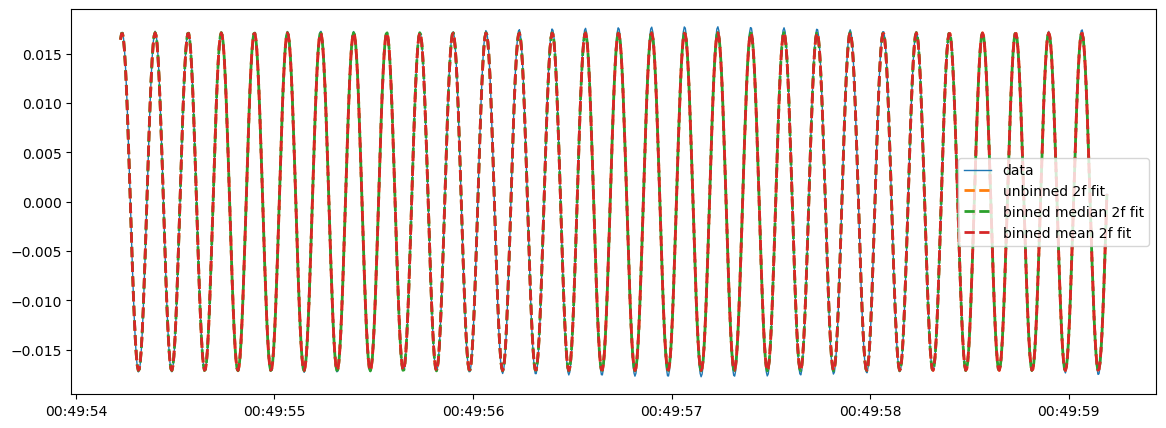

In [37]:
fig, ax = plt.subplots(figsize=(14,5))
slices = span.get_segments(unit='dpkg')

det = 0
i = 10

idx = slice(120800-1000, 120800)
zoom_slice = slice(slices[i].stop - 1000, slices[i].stop)
#zoom_slice = slices[0]

x = pd.to_datetime(span.tod.ctime, unit="s", utc=True)[zoom_slice]
det_index = filtered_span_data['det_uids'].index(det)

data = filtered_span_data['filtered_data'][det_index, zoom_slice]

encoder_data = filtered_span_data['encoder_data']
theta_slice = np.deg2rad(encoder_data[zoom_slice])

row = raw_fit[
    (raw_fit["segment_id"] == i) &
    (raw_fit["det_id"] == det)
]
print(f"{'type':>25}{'A':>20} {'B':>20} {'Total Amplitude':>12} {'Quality':>12}")
print(f"{'unbinned':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
fit = float(row['B'].iloc[0])*np.sin(2*theta_slice) + float(row['A'].iloc[0])*np.cos(2*theta_slice)
row = phase_fold_med[
    (phase_fold_med["segment_id"] == i) &
    (phase_fold_med["det_id"] == det)
]
print(f"{'binned median':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
phase_fold_med_fit = float(row['B'].iloc[0])*np.sin(2*theta_slice) + float(row['A'].iloc[0])*np.cos(2*theta_slice)

row = phase_fold_mean[
    (phase_fold_mean["segment_id"] == i) &
    (phase_fold_mean["det_id"] == det)
]
print(f"{'binned mean':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
phase_fold_mean_fit = float(row['B'].iloc[0])*np.sin(2*theta_slice) + float(row['A'].iloc[0])*np.cos(2*theta_slice)

plt.plot(x, data, label="data", linewidth=1)
plt.plot(x, fit, label="unbinned 2f fit", linestyle="--", linewidth=2)
plt.plot(x, phase_fold_med_fit, label="binned median 2f fit", linestyle="--", linewidth=2)
plt.plot(x, phase_fold_mean_fit, label="binned mean 2f fit", linestyle="--", linewidth=2)
plt.legend()

Text(0.5, 0.98, 'Phase Folded Filtered Data')

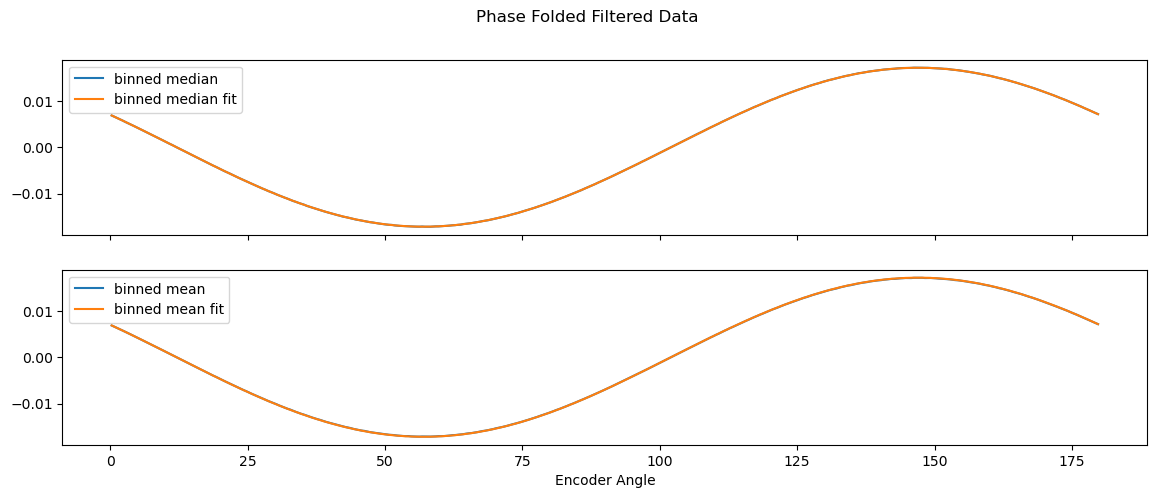

In [53]:
fig, ax = plt.subplots(2,1, sharex=True, figsize=(14,5))
slices = span.get_segments(unit='dpkg')

det = 0
i = 10
theta = np.deg2rad(encoder_data[slices[i]])
det_index = filtered_span_data['det_uids'].index(det)
bin_med = True

# bin_count = min(360, int(180.0 / max(0.5, np.median(np.diff(np.sort(np.unique(encoder_data)))))))
bin_count = 360
phase = encoder_data[slices[i]] % 180
bins = np.linspace(0, 180, bin_count + 1) # bin edges
bin_idx = np.digitize(phase, bins) - 1 # index of which bin each piece of data goes into 

bin_centers = (bins[1:] + bins[:-1]) / 2 # find middle of bin edges

signal = filtered_data[det_index,slices[i]]

# try phase folding and with raw data

template_med = np.zeros(bin_count) # mean signal at each bin
template_mean = np.zeros(bin_count) # mean signal at each bin
template_errors = np.zeros(bin_count)
bin_size = np.zeros(bin_count, dtype=int)

for j in range(bin_count):
    samples = signal[bin_idx == j]

    bin_size[j] = len(samples)

    if len(samples) > 0:
        template_med[j] = np.median(samples)
        template_mean[j] = np.mean(samples)

        if len(samples) > 1:
            template_errors[j] = np.std(samples, ddof=1) / np.sqrt(len(samples))

row = phase_fold_med[
    (phase_fold_med["segment_id"] == i) &
    (phase_fold_med["det_id"] == det)
]
phase_fold_med_fit = (
    float(row['A'].iloc[0]) * np.cos(2 * np.deg2rad(bin_centers))
    + float(row['B'].iloc[0]) * np.sin(2 * np.deg2rad(bin_centers))
)
row = phase_fold_med[
    (phase_fold_mean["segment_id"] == i) &
    (phase_fold_mean["det_id"] == det)
]
phase_fold_mean_fit = (
    float(row['A'].iloc[0]) * np.cos(2 * np.deg2rad(bin_centers))
    + float(row['B'].iloc[0]) * np.sin(2 * np.deg2rad(bin_centers))
)

ax[0].plot(bin_centers, template_med, label='binned median')
ax[0].plot(bin_centers, phase_fold_med_fit, label='binned median fit')
ax[1].plot(bin_centers, template_mean, label='binned mean')
ax[1].plot(bin_centers, phase_fold_mean_fit, label='binned mean fit')
ax[0].legend()
ax[1].legend()
plt.xlabel("Encoder Angle")
plt.suptitle("Phase Folded Filtered Data")

                     type                   A                    B Total Amplitude      Quality
                 unbinned        6.981056e-03        -1.560742e-02        1.709757e-02     0.999483
              binned mean        6.980967e-03        -1.560722e-02        1.709735e-02     0.999483


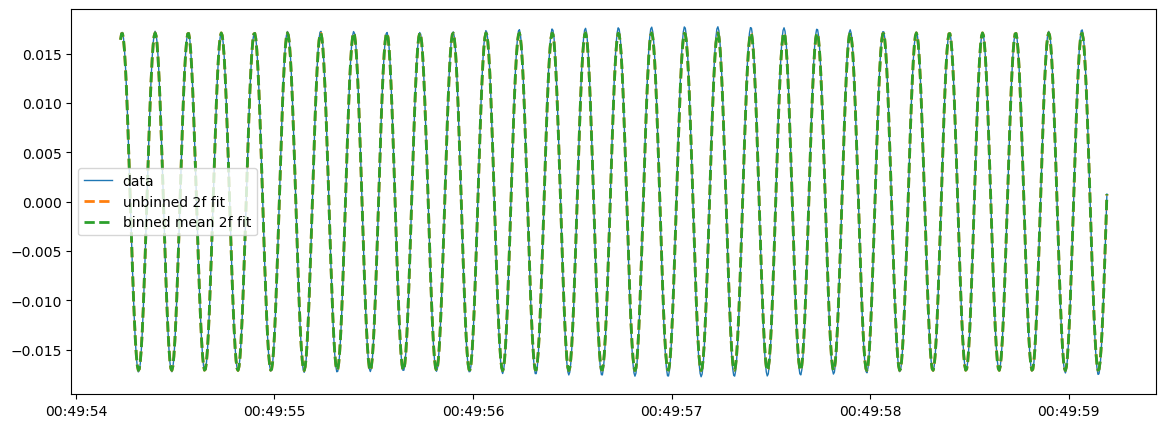

In [27]:
fig, ax = plt.subplots(figsize=(14,5))
slices = span.get_segments(unit='dpkg')

det = 0
i = 10

idx = slice(120800-1000, 120800)
zoom_slice = slice(slices[i].stop - 1000, slices[i].stop)
#zoom_slice = slices[0]

x = pd.to_datetime(span.tod.ctime, unit="s", utc=True)[zoom_slice]
det_index = filtered_span_data['det_uids'].index(det)

data = filtered_span_data['filtered_data'][det_index, zoom_slice]

encoder_data = filtered_span_data['encoder_data']
theta_slice = np.deg2rad(encoder_data[zoom_slice])

row = test_raw_fit[
    (test_raw_fit["segment_id"] == i) &
    (test_raw_fit["det_id"] == det)
]
print(f"{'type':>25}{'A':>20} {'B':>20} {'Total Amplitude':>12} {'Quality':>12}")
print(f"{'unbinned':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
fit = float(row['B'].iloc[0])*np.sin(2*theta_slice) + float(row['A'].iloc[0])*np.cos(2*theta_slice)
row = test_phase_fold_mean[
    (test_phase_fold_mean["segment_id"] == i) &
    (test_phase_fold_mean["det_id"] == det)
]
print(f"{'binned mean':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
phase_fold_mean_fit = float(row['B'].iloc[0])*np.sin(2*theta_slice) + float(row['A'].iloc[0])*np.cos(2*theta_slice)

plt.plot(x, data, label="data", linewidth=1)
plt.plot(x, fit, label="unbinned 2f fit", linestyle="--", linewidth=2)
plt.plot(x, phase_fold_mean_fit, label="binned mean 2f fit", linestyle="--", linewidth=2)
plt.legend()

                     type                   A                    B Total Amplitude      Quality
                 unbinned        2.456081e-09         2.001942e-08        2.016952e-08     0.000000
              binned mean        2.456081e-09         2.001942e-08        2.016952e-08     0.000000


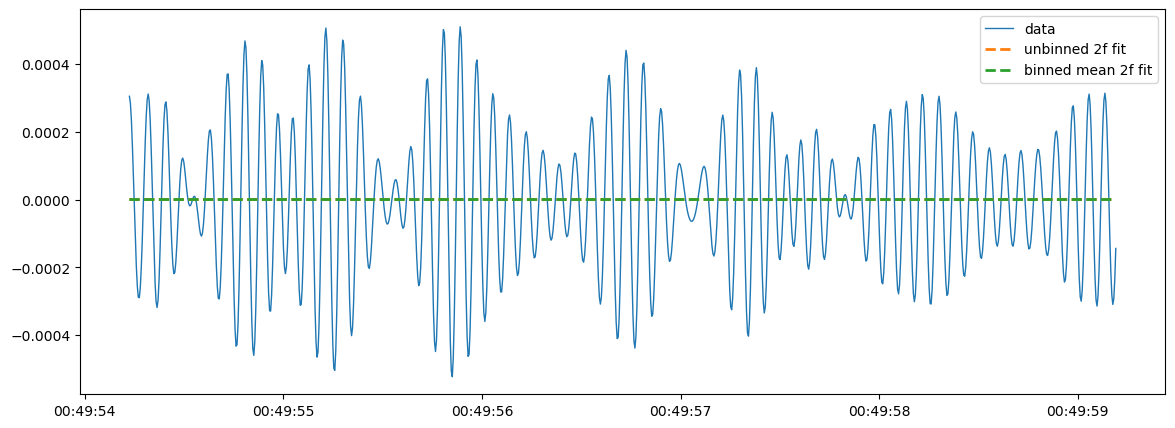

In [ ]:
fig, ax = plt.subplots(figsize=(14,5))
slices = span.get_segments(unit='dpkg')

det = 3
i = 10

#idx = slice(120800-1000, 120800)
zoom_slice = slice(slices[i].stop - 1000, slices[i].stop)
#zoom_slice = slices[0]

x = pd.to_datetime(span.tod.ctime, unit="s", utc=True)[zoom_slice]
det_index = filtered_span_data['det_uids'].index(det)

data = filtered_span_data['filtered_data'][det_index, zoom_slice]

encoder_data = filtered_span_data['encoder_data']
theta_slice = np.deg2rad(encoder_data[zoom_slice])

row = df_4f[
    (df_4f["segment_id"] == i) &
    (df_4f["det_id"] == det)
]
print(f"{'type':>25}{'A':>20} {'B':>20} {'Total Amplitude':>12} {'Quality':>12}")
print(f"{'unbinned':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
fit = float(row['B'].iloc[0])*np.sin(4*theta_slice) + float(row['A'].iloc[0])*np.cos(4*theta_slice)
row = df_4f[
    (df_4f["segment_id"] == i) &
    (df_4f["det_id"] == det)
]
print(f"{'binned mean':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
phase_fold_mean_fit = float(row['B'].iloc[0])*np.sin(4*theta_slice) + float(row['A'].iloc[0])*np.cos(4*theta_slice)

plt.plot(x, data, label="data", linewidth=1)
plt.plot(x, fit, label="unbinned 2f fit", linestyle="--", linewidth=2)
plt.plot(x, phase_fold_mean_fit, label="binned mean 2f fit", linestyle="--", linewidth=2)
plt.legend()

                     type                   A                    B Total Amplitude      Quality
                 unbinned       -2.244674e-07         1.344478e-08        2.248697e-07     0.000000
              binned mean       -2.244674e-07         1.344478e-08        2.248697e-07     0.000000


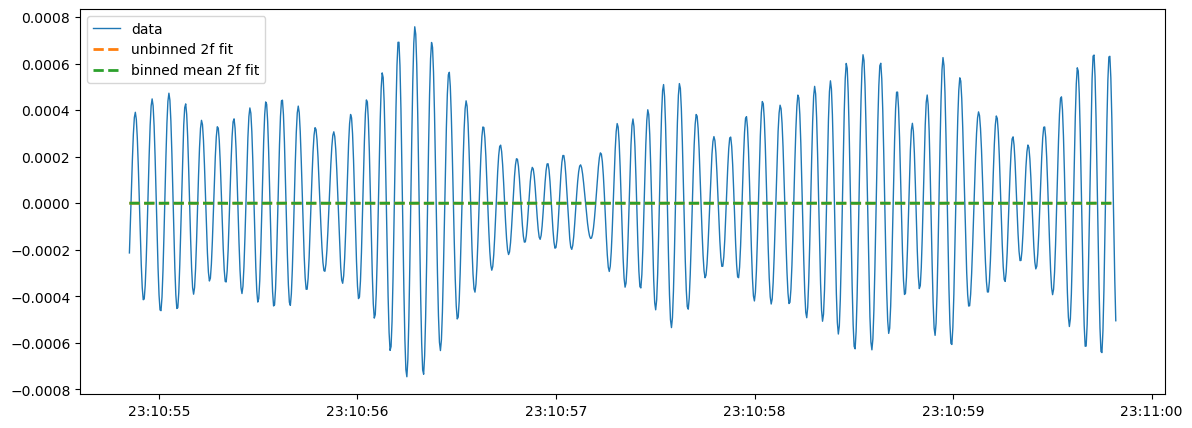

In [45]:
fig, ax = plt.subplots(figsize=(14,5))
slices = span.get_segments(unit='dpkg')

n = 10
small_slices = []
for dpkg in slices:
    start = dpkg.start
    stop = dpkg.stop

    edges = np.linspace(start, stop, n + 1).astype(int)

    for i in range(n):
        small_slices.append(slice(edges[i], edges[i+1]))

slices = small_slices

det = 3
i = 10

#idx = slice(120800-1000, 120800)
zoom_slice = slice(slices[i].stop - 1000, slices[i].stop)
#zoom_slice = slices[0]

x = pd.to_datetime(span.tod.ctime, unit="s", utc=True)[zoom_slice]
det_index = filtered_span_data['det_uids'].index(det)

data = filtered_span_data['filtered_data'][det_index, zoom_slice]

encoder_data = filtered_span_data['encoder_data']
theta_slice = np.deg2rad(encoder_data[zoom_slice])

row = df_4f_minute[
    (df_4f_minute["segment_id"] == i) &
    (df_4f_minute["det_id"] == det)
]
print(f"{'type':>25}{'A':>20} {'B':>20} {'Total Amplitude':>12} {'Quality':>12}")
print(f"{'unbinned':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
fit = float(row['B'].iloc[0])*np.sin(4*theta_slice) + float(row['A'].iloc[0])*np.cos(4*theta_slice)
row = df_4f_minute[
    (df_4f_minute["segment_id"] == i) &
    (df_4f_minute["det_id"] == det)
]
print(f"{'binned mean':>25}{row['A'].iloc[0]:20.6e} {row['B'].iloc[0]:20.6e}{row['amplitude'].iloc[0]:20.6e} {row['quality'].iloc[0]:>12.6f}")
phase_fold_mean_fit = float(row['B'].iloc[0])*np.sin(4*theta_slice) + float(row['A'].iloc[0])*np.cos(4*theta_slice)

plt.plot(x, data, label="data", linewidth=1)
plt.plot(x, fit, label="unbinned 2f fit", linestyle="--", linewidth=2)
plt.plot(x, phase_fold_mean_fit, label="binned mean 2f fit", linestyle="--", linewidth=2)
plt.legend()

In [ ]:
good_quality_fit = (
    one_minute_span1_fit.groupby('det_id')['quality'].mean()>0.95
)

drift = (
    one_minute_span1_fit.groupby('det_id')['amplitude'].apply(lambda x: (x > 0.001).std())
)

det_id
0      1.000000
1      1.000000
2      0.025806
3      1.000000
4      1.000000
         ...   
609    1.000000
612    1.000000
613    1.000000
614    1.000000
615    1.000000
Name: quality, Length: 334, dtype: float64

In [57]:
# get detectors where at least 90% of segments have fit quality of 0.95
good_fit = one_minute_span1_fit.groupby('det_id').filter(
    lambda x: (x['quality'] > 0.95).mean() >= 0.9
)
variability = (
    good_fit.groupby('det_id')['amplitude'].std()
)
# get detectors with good fit that have standard deviation of over 0.001 in their fitted amplitudes
drift_dets = variability[variability > 0.001].index.tolist()
print(len(drift_dets))

sort_var = (
    good_fit.groupby('det_id')['amplitude']
      .std()
      .sort_values(ascending=False)
)
print(sort_var.head(20))


39
det_id
89     0.008520
614    0.005168
542    0.003629
301    0.003329
539    0.002684
225    0.002669
110    0.002651
282    0.002537
595    0.002536
243    0.002447
168    0.002264
127    0.002115
126    0.002036
156    0.001863
336    0.001849
277    0.001806
302    0.001764
128    0.001763
330    0.001746
338    0.001722
Name: amplitude, dtype: float64


In [28]:
print(one_minute_span1_fit.groupby('det_id')['amplitude'].std().mean())

0.0009622792359534722


Text(0.5, 1.0, 'Det UID 614, std: 0.005168')

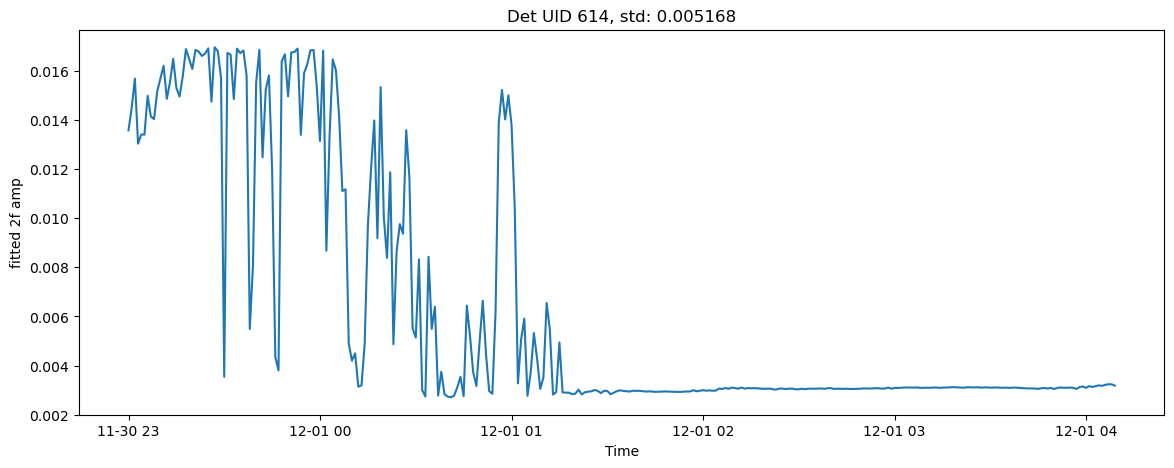

In [72]:
fig, ax = plt.subplots(figsize=(14,5))
det = 614

#x = pd.to_datetime(one_minute_span1_fit['timestamp'].unique(), unit="s", utc=True)
x = pd.to_datetime(one_minute_span1_fit[one_minute_span1_fit['det_id'] == det]['timestamp'], unit="s", utc=True)
det_index = filtered_span_data['det_uids'].index(det)

#data = filtered_span_data['filtered_data'][det_index]
plt.plot(x, one_minute_span1_fit[one_minute_span1_fit['det_id'] == det]['amplitude'])
plt.xlabel("Time")
plt.ylabel("fitted 2f amp")
plt.title(f"Det UID {det}, std: {good_fit[good_fit['det_id']==det]['amplitude'].std():.6f}")


# COMMON MODE and DRIFT

In [10]:
test_raw = vfit.extract_templates_from_span(span, filtered_span_data, binning=False, bin_med=False, n=10, verbose=True)

Extracting templates from 310 segments...


In [11]:
rows = []

for timestamp, detectors in test_raw.items():
    for det_id, values in detectors.items():
        rows.append({
            "timestamp": float(timestamp),   # or pd.to_datetime(float(timestamp), unit="s")
            "det_uid": det_id,
            "amplitude": values["amplitude"],
            "scaling_factor": values["scaling_factor"],
            "quality": values["quality"],
            "A": values['A'],
            "B": values['B'],
            "C": values['C'],
            "segment_id": values['segment_id']
        })

test_raw_fit = pd.DataFrame(rows)

In [15]:
common_mode = test_raw_fit.groupby('segment_id')[['amplitude', 'A', 'B', 'C']].mean()

In [16]:
common_mode

,amplitude,A,B,C
segment_id,,,,
0,0.015660,0.002361,0.001234,-1.038721e-06
1,0.015700,0.002381,0.001269,4.013894e-09
2,0.015878,0.002401,0.001318,-4.219578e-08
3,0.015601,0.002372,0.001232,3.156268e-08
4,0.015543,0.002380,0.001251,5.443061e-08
...,...,...,...,...
305,0.017763,0.002332,0.001270,-1.133783e-08
306,0.017833,0.002337,0.001292,-8.517386e-09
307,0.017926,0.002301,0.001281,-4.290457e-08


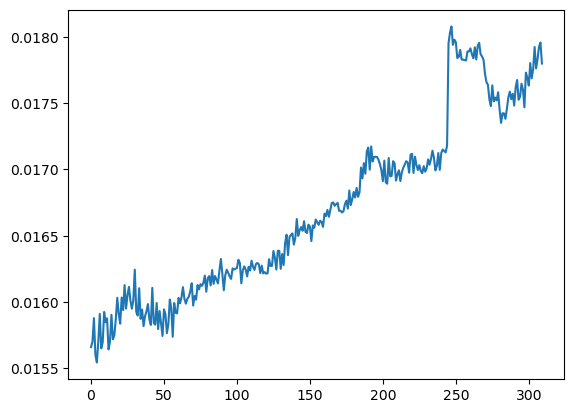

In [18]:
plt.plot(common_mode.index, common_mode['amplitude'])